# Red neuronal tabular con embeddings — Predicción de Estrés


El objetivo es predecir el nivel de **estrés futuro** en una zona geográfica, agregado por hora y día. Se definen **tres targets** distintos que representan el estrés en diferentes horizontes temporales:
 
| Target | Horizonte |
|---|---|
| `target_stress_t1` | +1 hora |
| `target_stress_t3` | +3 horas |
| `target_stress_t24` | +24 horas |
 
Se entrena **un modelo independiente por target**, todos con la misma arquitectura: **red neuronal tabular en PyTorch con embeddings para categóricas**, usando Spark únicamente para lectura, filtrado y partición temporal del dataset.

En los resultados adjuntos para este notebook se dispone del experimento `target_stress_t24`, por lo que el análisis queda centrado en el horizonte **+24h**. El código está preparado para incorporar automáticamente `t1` y `t3` si existen sus carpetas de salida correspondientes.


Los datos provienen de un dataset de parquets particionados en `data/aggregated/ex_stress/df_stress_zone_hour_day`. Se filtran filas donde el target o el timestamp sean nulos.
 
La partición es **temporal estricta** (no aleatoria), lo cual es crítico para evitar data leakage en series temporales:
 
```text
Train: 70%  →  Val: 15%  →  Test: 15%
```
 
El split se hace por `timestamp_hour`, preservando el orden cronológico. En el experimento +24h los cortes fueron:

| Split | Fecha |
|---|---|
| Fin de train | `2025-02-07 13:00:00` |
| Inicio de validation | `2025-02-07 14:00:00` |
| Fin de validation | `2025-07-20 18:00:00` |
| Inicio de test | `2025-07-20 19:00:00` |


## Preprocesamiento y pipeline
 
El pipeline del modelo neuronal tiene las siguientes etapas en orden:
 
### a) Preparación con Spark
- Se lee el parquet completo con Spark.
- Se aplica el filtro de `timestamp_hour` y del target no nulo.
- Se realiza un split temporal estricto `train → validation → test`.
- Tras el split, los subconjuntos se materializan para evitar recálculos.

### b) Preprocesamiento para PyTorch
- Las columnas numéricas se imputan con la mediana de train y se estandarizan con media/desviación típica de train.
- Las columnas categóricas se transforman con mapas aprendidos en train, reservando índice `0` para valores desconocidos (`<UNK>`).
- En este experimento hay **32 variables numéricas** y **1 categórica** (`borough`), con **8 categorías**.

### c) Modelo
- `EmbeddingMLPRegressor` combina las numéricas escaladas con embeddings aprendidos para categóricas.
- La red usa capas densas `64 → 32`, activación `ReLU` y `Dropout`.
- Se entrena directamente sobre la escala del stress con `SmoothL1Loss`, lo que hace el entrenamiento más robusto frente a valores extremos que un MSE puro.


## Hiperparámetros
 
**Defaults conservadores** utilizados por el script `d_model_nn.py` y confirmados en el report adjunto:
 
| Parámetro | Valor | Descripción |
|---|---:|---|
| `nn_hidden_dims` | `64,32` | Arquitectura de capas ocultas del MLP |
| `nn_dropout` | `0.15` | Regularización por apagado aleatorio de neuronas |
| `nn_learning_rate` | `0.001` | Learning rate inicial de AdamW |
| `nn_weight_decay` | `1e-05` | Regularización L2 del optimizador |
| `nn_batch_size` | `2048` | Tamaño de batch |
| `nn_max_epochs` | `30` | Máximo de épocas |
| `nn_patience` | `5` | Early stopping si validation no mejora |
| `nn_embedding_dim_cap` | `12` | Dimensión máxima de los embeddings categóricos |
| `device` | `cuda` | Entrenamiento ejecutado en GPU |


## Búsqueda de hiperparámetros (tuning)
 
Cuando se activa `--tune`, el script realiza un **grid search manual sobre validación temporal**:
 
- Grid por defecto: arquitecturas `256,128,64` y `512,256,128`, `dropout ∈ {0.15,0.25}`, `lr ∈ {1e-3,5e-4}`, `weight_decay ∈ {1e-5,5e-5}`, `batch_size ∈ {1024,2048}` y `embedding_dim_cap ∈ {24,32}`.
- Se muestrea una fracción de train/val para acelerar (`tune_train_sample_frac`, `tune_val_sample_frac`).
- Métrica de selección configurable: `rmse` (default), `mae`, o `r2`.
- El mejor trial se guarda en `neural_network_stress_tuning_report.json` y todos los trials en `neural_network_stress_tuning_trials.csv`.

En el resultado adjunto, el tuning aparece como **desactivado** (`enabled=false`), por lo que se evalúa la configuración base `64,32`.


## Protocolo de entrenamiento y evaluación
 
```text
[Train] → fit red neuronal → predice en Train, Val, Test  (detectar overfitting)
           ↓
[Validation] → early stopping y reducción de learning rate
           ↓
[Test] → evaluación final sobre datos futuros no vistos
```
 
- El **modelo base** se entrena solo con train y usa validation para controlar el entrenamiento.
- En este experimento **no se activó** `--refit-train-val`; por tanto, el modelo final guardado corresponde al entrenamiento en train con early stopping sobre validation.
- Opcionalmente, `--fit-all-data` entrena un tercer modelo sobre train+val+test para despliegue, pero sus métricas son in-sample y no válidas para medir generalización.

**Métricas calculadas:** `MAE`, `RMSE`, `R²`
 
**Overfit gaps calculados automáticamente:**
- `val_rmse - train_rmse`
- `test_rmse - train_rmse`
- `train_r2 - val_r2`
- `train_r2 - test_r2`


## A) Análisis numérico


**1. Desempeño y Generalización**

A partir de las métricas obtenidas para el horizonte temporal +24h, podemos extraer tres conclusiones clave que validan la robustez del modelo neuronal:

- **Ausencia de overfitting relevante:** La diferencia entre train y datos no vistos es reducida. El $R^2$ pasa de **0.7677** en train a **0.7558** en validation y **0.7524** en test. La caída frente al test es de solo **0.0153 puntos de $R^2$**, lo que indica que la red no se limita a memorizar la serie histórica.

- **Alto poder predictivo general:** El modelo explica aproximadamente el **75.24% de la varianza** del estrés futuro a +24h en datos completamente posteriores al entrenamiento. Además, el error medio absoluto se mantiene en **0.4931** puntos en test, una desviación contenida para una variable sintética de estrés urbano.

- **Buen encaje para el horizonte diario:** El objetivo +24h se beneficia de la fuerte **estacionalidad diaria** de Nueva York. La red neuronal captura patrones repetitivos de demanda, precio, clima, eventos y zona, apoyándose en variables de lag/rolling y en el embedding de `borough` para representar diferencias espaciales.


In [8]:
import json
import os
from pathlib import Path
import copy
import numpy as np
import pandas as pd

# Resultados adjuntos embebidos para que el notebook sea ejecutable incluso
# si todavía no está situado dentro de la carpeta del proyecto.
EMBEDDED_REPORTS = {
  "t24": {
    "model": "EmbeddingMLPRegressor_torch",
    "input_dir": "/home/daniel/pd2/Grupo-PD2---Transporte-NYC/data/aggregated/ex_stress/df_stress_zone_hour_day",
    "target_col": "target_stress_t24",
    "time_col": "timestamp_hour",
    "extra_drop_cols": None,
    "split_params": {
      "train_frac": 0.7,
      "val_frac": 0.15,
      "bounds": {
        "train_end": "2025-02-07 13:00:00",
        "val_start": "2025-02-07 14:00:00",
        "val_end": "2025-07-20 18:00:00",
        "test_start": "2025-07-20 19:00:00"
      }
    },
    "features": {
      "numeric": [
        "year",
        "month",
        "hour",
        "hour_block_3h",
        "day_of_week",
        "is_weekend",
        "pu_location_id",
        "n_trips",
        "price_variability",
        "avg_price",
        "lag_1h_trips",
        "lag_24h_trips",
        "lag_168h_trips",
        "roll_3h_trips",
        "roll_24h_trips",
        "lag_1h_price_variability",
        "lag_24h_price_variability",
        "roll_3h_price_variability",
        "roll_24h_price_variability",
        "lag_1h_avg_price",
        "lag_24h_avg_price",
        "roll_24h_avg_price",
        "temp_c",
        "precip_mm",
        "city_n_events",
        "city_has_event",
        "n_restaurants_zone",
        "n_cuisines_zone",
        "rent_price_zone",
        "z_price_variability",
        "z_log1p_num_trips",
        "stress_score"
      ],
      "categorical": [
        "borough"
      ],
      "n_numeric": 32,
      "n_categorical": 1,
      "categorical_encoding": "learned_embeddings",
      "cat_cardinalities": [
        8
      ]
    },
    "training_params": {
      "nn_hidden_dims": "64,32",
      "nn_dropout": 0.15,
      "nn_learning_rate": 0.001,
      "nn_weight_decay": 1e-05,
      "nn_batch_size": 2048,
      "nn_max_epochs": 30,
      "nn_patience": 5,
      "nn_embedding_dim_cap": 12,
      "device": "cuda"
    },
    "training_protocol": {
      "tuning": "train -> val",
      "post_tuning_refit": "train -> test",
      "final_model_training_data": "train",
      "fit_all_data_enabled": False
    },
    "metrics": {
      "train_fit": {
        "train_seen": {
          "mae": 0.4660509863972013,
          "rmse": 0.7712726459622851,
          "r2": 0.7676736452870716
        },
        "val_unseen": {
          "mae": 0.4775921411971243,
          "rmse": 0.8051389718107851,
          "r2": 0.75577057105687
        },
        "test_unseen": {
          "mae": 0.49310710453912493,
          "rmse": 0.8262148201150505,
          "r2": 0.7524017959194924
        },
        "overfit_gaps": {
          "val_minus_train_rmse": 0.03386632584850002,
          "test_minus_train_rmse": 0.05494217415276548,
          "train_minus_val_r2": 0.011903074230201649,
          "train_minus_test_r2": 0.015271849367579193
        }
      },
      "train_val_refit": None,
      "all_data_fit": None
    },
    "tuning": {
      "enabled": False,
      "selected_params": {
        "nn_hidden_dims": "64,32",
        "nn_dropout": 0.15,
        "nn_learning_rate": 0.001,
        "nn_weight_decay": 1e-05,
        "nn_batch_size": 2048,
        "nn_max_epochs": 30,
        "nn_patience": 5,
        "nn_embedding_dim_cap": 12
      }
    },
    "artifacts": {
      "model_pt": "/home/daniel/pd2/Grupo-PD2---Transporte-NYC/outputs/ejercicio2/nn/t24/neural_network_stress_model.pt",
      "all_data_model_pt": None,
      "feature_importance_csv": None,
      "training_history_csv": "/home/daniel/pd2/Grupo-PD2---Transporte-NYC/outputs/ejercicio2/nn/t24/neural_network_training_history.csv"
    }
  }
}
EMBEDDED_HISTORY = {
  "t24": [
    {
      "epoch": 1.0,
      "train_loss": 0.24728017396097554,
      "val_loss": 0.2250116905179132,
      "lr": 0.001
    },
    {
      "epoch": 2.0,
      "train_loss": 0.22232965043008276,
      "val_loss": 0.2251536615075327,
      "lr": 0.001
    },
    {
      "epoch": 3.0,
      "train_loss": 0.21711341357795444,
      "val_loss": 0.22289965759514588,
      "lr": 0.001
    },
    {
      "epoch": 4.0,
      "train_loss": 0.21466699856020893,
      "val_loss": 0.22053412730113053,
      "lr": 0.001
    },
    {
      "epoch": 5.0,
      "train_loss": 0.2130520406823892,
      "val_loss": 0.2203861645825163,
      "lr": 0.001
    },
    {
      "epoch": 6.0,
      "train_loss": 0.21195580290090402,
      "val_loss": 0.22259097295047264,
      "lr": 0.001
    },
    {
      "epoch": 7.0,
      "train_loss": 0.2111109311134253,
      "val_loss": 0.21637117305010029,
      "lr": 0.001
    },
    {
      "epoch": 8.0,
      "train_loss": 0.21060984444411648,
      "val_loss": 0.2151219673983797,
      "lr": 0.001
    },
    {
      "epoch": 9.0,
      "train_loss": 0.21015553202225007,
      "val_loss": 0.21871133451395958,
      "lr": 0.001
    },
    {
      "epoch": 10.0,
      "train_loss": 0.20978855864410167,
      "val_loss": 0.2173251395629943,
      "lr": 0.001
    },
    {
      "epoch": 11.0,
      "train_loss": 0.20923890466294043,
      "val_loss": 0.2161262171522988,
      "lr": 0.0005
    },
    {
      "epoch": 12.0,
      "train_loss": 0.20856772936307466,
      "val_loss": 0.2183946649850708,
      "lr": 0.0005
    },
    {
      "epoch": 13.0,
      "train_loss": 0.2083450254440207,
      "val_loss": 0.22125021050843965,
      "lr": 0.0005
    }
  ]
}

# Rutas esperadas dentro del repositorio.
BASE_PATH = Path("../outputs/ejercicio2/nn")
DATA_PATH = Path("../data/aggregated/ex_stress/df_stress_zone_hour_day")
REQUESTED_TARGETS = ["t1", "t3", "t24"]
HORIZON_LABELS = {"t1": "+1h", "t3": "+3h", "t24": "+24h"}


def _candidate_report_paths(target: str):
    return [
        BASE_PATH / target / "neural_network_stress_report.json",
        BASE_PATH / f"{target}" / "neural_network_stress_report.json",
        BASE_PATH / "neural_network_stress_report.json",
        Path(f"neural_network_stress_report_{target}.json"),
        Path("neural_network_stress_report.json"),
        Path("neural_network_stress_report (1).json"),
    ]


def load_report(target: str):
    for path in _candidate_report_paths(target):
        if path.exists():
            with open(path, "r", encoding="utf-8") as f:
                report = json.load(f)
            # Evitamos cargar el mismo report para todos los targets si su target_col no coincide.
            if report.get("target_col", "").endswith(target):
                return report
    if target in EMBEDDED_REPORTS:
        return copy.deepcopy(EMBEDDED_REPORTS[target])
    return None


def get_final_test_metrics(report: dict):
    metrics = report.get("metrics", {})
    refit = metrics.get("train_val_refit") or {}
    if refit.get("test_unseen"):
        return refit["test_unseen"]
    return metrics.get("train_fit", {}).get("test_unseen", {})


reports = {t: load_report(t) for t in REQUESTED_TARGETS}
reports = {t: r for t, r in reports.items() if r is not None}
targets = list(reports.keys())
horizontes = [HORIZON_LABELS[t] for t in targets]

results = []

for target, data in reports.items():
    metrics = data.get("metrics", {})
    train_fit = metrics.get("train_fit", {})

    # Extraemos Train y Val del primer fit (para evaluar el overfit puro)
    train_metrics = train_fit.get("train_seen", {})
    val_metrics = train_fit.get("val_unseen", {})

    # Extraemos Test del modelo final disponible.
    # Si no hubo refit train+val, usamos train_fit.test_unseen, que es el caso del report adjunto.
    test_metrics = get_final_test_metrics(data)

    row = {
        "Target": HORIZON_LABELS[target],
        "Train R²": round(train_metrics.get("r2", np.nan), 4),
        "Val R²": round(val_metrics.get("r2", np.nan), 4),
        "Test Final R²": round(test_metrics.get("r2", np.nan), 4),
        "Train RMSE": round(train_metrics.get("rmse", np.nan), 4),
        "Val RMSE": round(val_metrics.get("rmse", np.nan), 4),
        "Test Final RMSE": round(test_metrics.get("rmse", np.nan), 4),
        "Train MAE": round(train_metrics.get("mae", np.nan), 4),
        "Val MAE": round(val_metrics.get("mae", np.nan), 4),
        "Test Final MAE": round(test_metrics.get("mae", np.nan), 4),
    }
    results.append(row)


df_metrics = pd.DataFrame(results)
display(df_metrics)


,Target,Train R²,Val R²,Test Final R²,Train RMSE,Val RMSE,Test Final RMSE,Train MAE,Val MAE,Test Final MAE
0,+24h,0.7677,0.7558,0.7524,0.7713,0.8051,0.8262,0.4661,0.4776,0.4931


**2. Overfit gaps**

Los resultados demuestran que el modelo de red neuronal generaliza de forma saludable sobre datos futuros. Las métricas de degradación entre datos vistos en entrenamiento y datos no vistos son contenidas:

- **Degradación controlada:** El RMSE sube de **0.7713** en train a **0.8051** en validation y **0.8262** en test. El gap test-train es de **0.0549**, razonable para un horizonte de 24 horas.

- **Consistencia entre validation y test:** La validación ya anticipa correctamente el rendimiento futuro: el RMSE de validation es **0.8051** y el de test **0.8262**, con una diferencia pequeña. Esto indica que la partición temporal está midiendo bien la generalización.

- **Validación de la arquitectura:** Mantener gaps estrechos confirma que las decisiones de diseño —capas `64,32`, `dropout=0.15`, `weight_decay=1e-5`, early stopping y embeddings categóricos— han funcionado correctamente, permitiendo que la red aprenda patrones reales sin memorizar ruido histórico.


In [9]:
results_gaps = []

for target, data in reports.items():
    metrics = data.get("metrics", {})

    # Extraemos los gaps del primer entrenamiento (Train -> Val/Test)
    train_fit_gaps = metrics.get("train_fit", {}).get("overfit_gaps", {}) or {}

    # Si existe refit train+val, también lo mostramos; si no, queda como NaN.
    refit_gaps = (metrics.get("train_val_refit") or {}).get("overfit_gaps", {}) or {}

    row = {
        "Target": HORIZON_LABELS[target],
        "Val - Train RMSE (Base)": round(train_fit_gaps.get("val_minus_train_rmse", np.nan), 4),
        "Test - Train RMSE (Base)": round(train_fit_gaps.get("test_minus_train_rmse", np.nan), 4),
        "Train - Val R² (Base)": round(train_fit_gaps.get("train_minus_val_r2", np.nan), 4),
        "Train - Test R² (Base)": round(train_fit_gaps.get("train_minus_test_r2", np.nan), 4),
        "Test - TrainVal RMSE (Final)": round(refit_gaps.get("test_minus_train_val_rmse", np.nan), 4),
        "TrainVal - Test R² (Final)": round(refit_gaps.get("train_val_minus_test_r2", np.nan), 4),
    }
    results_gaps.append(row)


df_gaps = pd.DataFrame(results_gaps)
display(df_gaps)


,Target,Val - Train RMSE (Base),Test - Train RMSE (Base),Train - Val R² (Base),Train - Test R² (Base),Test - TrainVal RMSE (Final),TrainVal - Test R² (Final)
0,+24h,0.0339,0.0549,0.0119,0.0153,NaN,NaN


**3. Análisis del tuning**

En este experimento, el tuning aparece desactivado. Esto significa que el resultado +24h corresponde a la configuración base del script, no a una búsqueda de hiperparámetros:

- **Configuración estable:** La red `64,32` con `dropout=0.15`, `lr=0.001`, `weight_decay=1e-5` y `batch_size=2048` ya alcanza un $R^2$ de **0.7524** en test.

- **Early stopping efectivo:** Aunque `nn_max_epochs=30`, el historial adjunto termina en la época **13**, lo que indica parada temprana tras varias épocas sin mejora suficiente en validation.

- **Siguiente mejora natural:** Si se quisiera apurar rendimiento, el siguiente paso sería activar `--tune` y comparar arquitecturas más anchas (`256,128,64` o `512,256,128`) contra la base, vigilando que los gaps de overfitting no aumenten.


In [10]:
rows = []

for target, report in reports.items():
    tuning = report.get("tuning", {}) or {}
    params = tuning.get("best_params") or tuning.get("selected_params") or report.get("training_params", {})
    rows.append({
        "Target": HORIZON_LABELS[target],
        "Tuning activo": tuning.get("enabled", False),
        "Hidden dims": params.get("nn_hidden_dims"),
        "Dropout": params.get("nn_dropout"),
        "Learning rate": params.get("nn_learning_rate"),
        "Weight decay": params.get("nn_weight_decay"),
        "Batch size": params.get("nn_batch_size"),
        "Embedding cap": params.get("nn_embedding_dim_cap"),
        "Max epochs": params.get("nn_max_epochs"),
        "Patience": params.get("nn_patience"),
    })

df_tuning = pd.DataFrame(rows)
display(df_tuning)


,Target,Tuning activo,Hidden dims,Dropout,Learning rate,Weight decay,Batch size,Embedding cap,Max epochs,Patience
0,+24h,False,"64,32",0.15,0.001,0.00001,2048,12,30,5


**4. Variables de entrada y feature importance**

La red neuronal utiliza una mezcla de señales temporales, operativas, económicas, contextuales y espaciales. En el report adjunto no existe `neural_network_stress_feature_importance.csv` porque `compute_importance=false`; por tanto, no se puede afirmar una importancia cuantitativa de cada feature sin ejecutar la importancia por permutación.

Aun así, el conjunto de entrada confirma una arquitectura informativa y coherente:

- **Variables de demanda y precio:** `n_trips`, `avg_price`, `price_variability`, `z_price_variability`, `z_log1p_num_trips` y `stress_score` resumen el estado actual del sistema.
- **Memoria temporal:** lags y rolling windows como `lag_24h_trips`, `lag_168h_trips`, `roll_24h_trips` o `roll_24h_price_variability` capturan inercia diaria/semanal.
- **Contexto externo:** clima, eventos, restauración y renta zonal ayudan a explicar variaciones de demanda no puramente temporales.
- **Componente espacial:** `borough` se codifica mediante un embedding aprendido, permitiendo que la red represente diferencias estructurales entre zonas sin expandir la dimensionalidad con one-hot.

Para obtener importancias reales, se puede reejecutar el script con `--compute-importance`; el notebook las cargará automáticamente si el CSV existe.


In [11]:
def find_existing_path(candidates):
    for p in candidates:
        if p is None:
            continue
        path = Path(p)
        if path.exists():
            return path
    return None


def artifact_candidates(report: dict, target: str, artifact_key: str, filename: str):
    raw = (report.get("artifacts", {}) or {}).get(artifact_key)
    return [
        raw,
        BASE_PATH / target / filename,
        BASE_PATH / filename,
        Path(filename),
        Path(f"{filename} (1)"),
    ]

importance_tables = []
feature_inventory = []

for target, report in reports.items():
    imp_path = find_existing_path(
        artifact_candidates(report, target, "feature_importance_csv", "neural_network_stress_feature_importance.csv")
    )

    if imp_path is not None:
        df_imp = pd.read_csv(imp_path)
        df_imp.insert(0, "Target", HORIZON_LABELS[target])
        importance_tables.append(df_imp)
    else:
        features = report.get("features", {})
        for feature in features.get("numeric", []):
            feature_inventory.append({"Target": HORIZON_LABELS[target], "feature": feature, "tipo": "numérica"})
        for feature in features.get("categorical", []):
            feature_inventory.append({"Target": HORIZON_LABELS[target], "feature": feature, "tipo": "categórica / embedding"})

if importance_tables:
    df_importance = pd.concat(importance_tables, ignore_index=True)
    display(df_importance.sort_values(["Target", "importance"], ascending=[True, False]).head(20))
else:
    df_feature_inventory = pd.DataFrame(feature_inventory)
    display(df_feature_inventory.head(40))
    print("No se encontró CSV de importancias. Ejecuta d_model_nn.py con --compute-importance para generar neural_network_stress_feature_importance.csv.")


,Target,feature,tipo
0,+24h,year,numérica
1,+24h,month,numérica
2,+24h,hour,numérica
3,+24h,hour_block_3h,numérica
4,+24h,day_of_week,numérica
5,+24h,is_weekend,numérica
6,+24h,pu_location_id,numérica
7,+24h,n_trips,numérica
8,+24h,price_variability,numérica
9,+24h,avg_price,numérica


No se encontró CSV de importancias. Ejecuta d_model_nn.py con --compute-importance para generar neural_network_stress_feature_importance.csv.


## B) Análisis gráfico


**1. Barchart de variables / importancias**


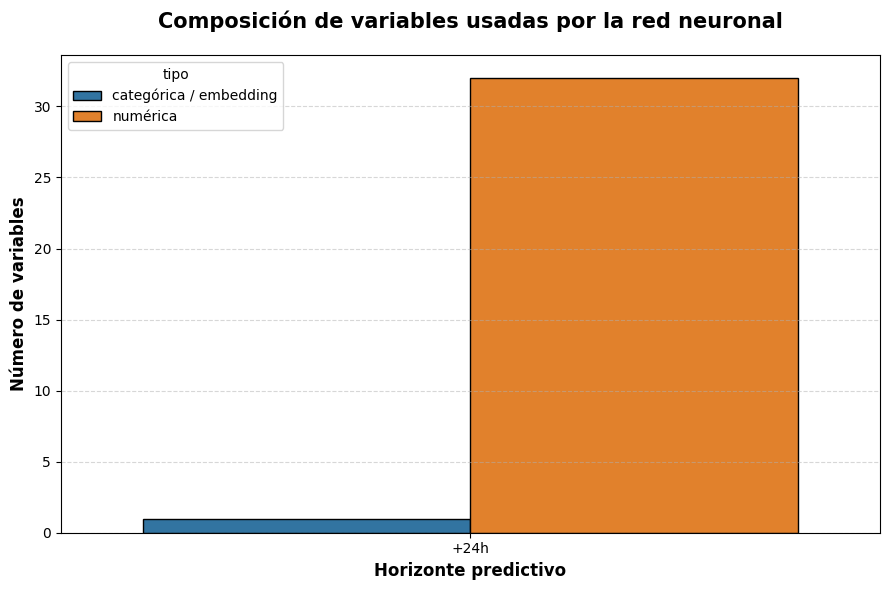

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

if "df_importance" in globals() and not df_importance.empty and "importance" in df_importance.columns:
    df_top = df_importance.sort_values("importance", ascending=False).head(15).copy()

    plt.figure(figsize=(12, 7))
    sns.barplot(data=df_top, y="feature", x="importance", hue="Target", dodge=False)
    plt.title("Top variables por importancia de permutación", fontsize=15, fontweight="bold", pad=20)
    plt.xlabel("Incremento de MAE al permutar la variable", fontsize=12, fontweight="bold")
    plt.ylabel("Variable (Feature)", fontsize=12, fontweight="bold")
    plt.grid(axis="x", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()
else:
    # Como no se adjuntó feature_importance_csv, visualizamos la composición del input.
    feature_counts = (
        df_feature_inventory.groupby(["Target", "tipo"])
        .size()
        .reset_index(name="n_features")
    )

    plt.figure(figsize=(9, 6))
    sns.barplot(data=feature_counts, x="Target", y="n_features", hue="tipo", edgecolor="black")
    plt.title("Composición de variables usadas por la red neuronal", fontsize=15, fontweight="bold", pad=20)
    plt.xlabel("Horizonte predictivo", fontsize=12, fontweight="bold")
    plt.ylabel("Número de variables", fontsize=12, fontweight="bold")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()


**2. Heatmap de métricas**


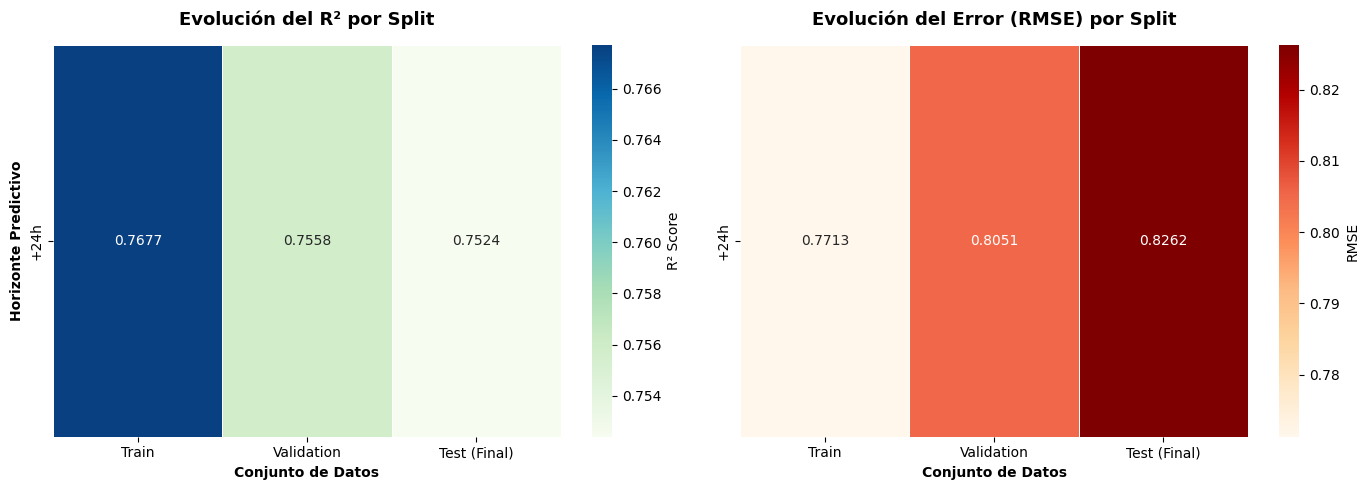

In [13]:
# Separar las métricas en dos DataFrames distintos para los heatmaps
df_r2 = df_metrics.set_index("Target")[["Train R²", "Val R²", "Test Final R²"]]
df_rmse = df_metrics.set_index("Target")[["Train RMSE", "Val RMSE", "Test Final RMSE"]]

# Renombrar columnas para que quede más limpio en el gráfico
df_r2.columns = ["Train", "Validation", "Test (Final)"]
df_rmse.columns = ["Train", "Validation", "Test (Final)"]

# Crear la figura con dos subplots lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap R²: más alto es mejor
sns.heatmap(df_r2, annot=True, fmt=".4f", cmap="GnBu", ax=axes[0],
            cbar_kws={"label": "R² Score"}, linewidths=.5)
axes[0].set_title("Evolución del R² por Split", pad=15, fontweight="bold", fontsize=13)
axes[0].set_ylabel("Horizonte Predictivo", fontweight="bold")
axes[0].set_xlabel("Conjunto de Datos", fontweight="bold")

# Heatmap RMSE: más alto es peor/más error
sns.heatmap(df_rmse, annot=True, fmt=".4f", cmap="OrRd", ax=axes[1],
            cbar_kws={"label": "RMSE"}, linewidths=.5)
axes[1].set_title("Evolución del Error (RMSE) por Split", pad=15, fontweight="bold", fontsize=13)
axes[1].set_ylabel("")
axes[1].set_xlabel("Conjunto de Datos", fontweight="bold")

plt.tight_layout()
plt.show()


**3. Scatter plot: predicciones vs. valores reales**

La red neuronal debe reproducir adecuadamente la tendencia general entre valores reales y predichos. En un buen ajuste, la densidad de puntos se alinea con la diagonal ideal. Para modelos de estrés urbano es habitual observar cierta regresión a la media: los valores extremos altos pueden quedar algo subestimados y los valores muy bajos algo sobreestimados.

La celda siguiente reconstruye las predicciones del modelo `.pt` guardado. Si se ejecuta fuera del repositorio o sin el dataset/modelo, la celda avisa y no rompe el notebook.


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/04/29 19:16:20 WARN Utils: Your hostname, vegapc, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/04/29 19:16:20 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/29 19:16:22 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/29 19:16:29 WARN DataSource: [COLUMN_ALREADY_EXISTS] The column `month` already exists. Choose another name or rename the existing column. SQLSTATE: 42711
26/04/29 19:16:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxT

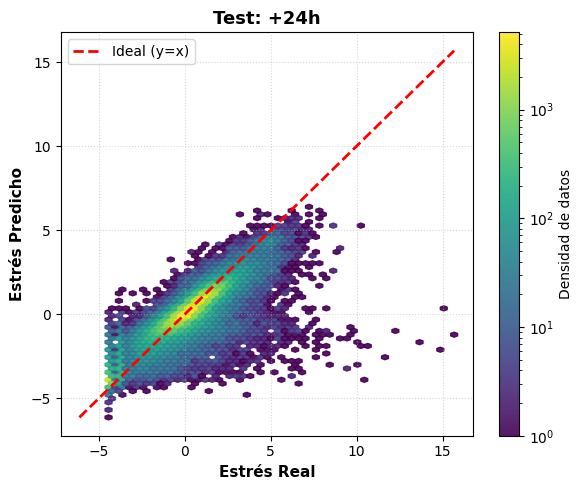

In [17]:
# Helpers para reconstruir predicciones de la red neuronal guardada.
# Requiere ejecutar el notebook dentro del repositorio con PySpark, PyTorch, el parquet y el .pt disponibles.

prediction_frames = {}
RUN_MODEL_PLOTS = True
MAX_PRED_ROWS = 120_000


def _load_history(target: str, report: dict):
    hist_path = find_existing_path(
        artifact_candidates(report, target, "training_history_csv", "neural_network_training_history.csv")
        + [Path("neural_network_training_history (1).csv")]
    )
    if hist_path is not None:
        return pd.read_csv(hist_path)
    if target in EMBEDDED_HISTORY:
        return pd.DataFrame(EMBEDDED_HISTORY[target])
    return pd.DataFrame()


def _find_model_path(report: dict, target: str):
    return find_existing_path(
        artifact_candidates(report, target, "model_pt", "neural_network_stress_model.pt")
        + [
            Path("neural_network_stress_model.pt"),
            Path("neural_network_stress_model.pt (1)"),
            Path("neural_network_stress_model.pt.zip"),
            Path("neural_network_stress_model.pt (1).zip"),
        ]
    )


def _build_prediction_dataframe(target: str, report: dict, max_rows: int = MAX_PRED_ROWS):
    try:
        import torch
        from torch import nn
        from pyspark.sql import SparkSession
        import pyspark.sql.functions as F
    except Exception as e:
        print(f"No se pueden generar predicciones para {target}: faltan dependencias ({e}).")
        return pd.DataFrame()

    model_path = _find_model_path(report, target)
    if model_path is None:
        print(f"No se encontró el modelo .pt para {target}. Esperado en ../outputs/ejercicio2/nn/{target}/neural_network_stress_model.pt")
        return pd.DataFrame()

    if not DATA_PATH.exists():
        print(f"No se encontró el dataset en {DATA_PATH}. Ejecuta el notebook desde la carpeta de notebooks del proyecto.")
        return pd.DataFrame()

    class EmbeddingMLPRegressor(nn.Module):
        def __init__(self, num_numeric, cat_cardinalities, embedding_dim_cap=12, hidden_dims=(64, 32), dropout=0.15):
            super().__init__()
            import math
            self.embeddings = nn.ModuleList()
            emb_total_dim = 0
            for card in cat_cardinalities:
                emb_dim = min(int(embedding_dim_cap), max(4, int(round(1.6 * math.sqrt(card)))))
                self.embeddings.append(nn.Embedding(num_embeddings=card, embedding_dim=emb_dim))
                emb_total_dim += emb_dim

            layers = []
            in_dim = int(num_numeric) + emb_total_dim
            for h in hidden_dims:
                layers.append(nn.Linear(in_dim, int(h)))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(float(dropout)))
                in_dim = int(h)
            layers.append(nn.Linear(in_dim, 1))
            self.mlp = nn.Sequential(*layers)

        def forward(self, x_num, x_cat):
            if self.embeddings:
                cat_parts = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
                x = torch.cat([x_num, *cat_parts], dim=1)
            else:
                x = x_num
            return self.mlp(x)

    def parse_hidden_dims(s):
        return tuple(int(v.strip()) for v in str(s).split(",") if v.strip())

    def apply_numeric_stats(pdf, num_cols, stats):
        arrs = []
        for c in num_cols:
            s = pd.to_numeric(pdf[c], errors="coerce")
            meta = stats[c]
            s = s.fillna(meta["median"])
            s = (s - meta["mean"]) / meta["std"]
            arrs.append(s.to_numpy(dtype=np.float32))
        return np.column_stack(arrs).astype(np.float32) if arrs else np.zeros((len(pdf), 0), dtype=np.float32)

    def apply_category_maps(pdf, cat_cols, cat_maps):
        cols = []
        for c in cat_cols:
            mapping = cat_maps[c]
            vals = pdf[c].astype("string").fillna("<MISSING>").astype(str)
            cols.append(vals.map(lambda x: mapping.get(x, 0)).to_numpy(dtype=np.int64))
        return np.column_stack(cols).astype(np.int64) if cols else np.zeros((len(pdf), 0), dtype=np.int64)

    try:
        artifact = torch.load(model_path, map_location="cpu", weights_only=False)
    except TypeError:
        artifact = torch.load(model_path, map_location="cpu")

    num_cols = artifact.get("num_cols", report.get("features", {}).get("numeric", []))
    cat_cols = artifact.get("cat_cols", report.get("features", {}).get("categorical", []))
    num_stats = artifact.get("num_stats")
    cat_maps = artifact.get("cat_maps")
    params = artifact.get("selected_params", report.get("training_params", {}))
    target_col = artifact.get("target_col", report.get("target_col", f"target_stress_{target}"))

    if num_stats is None or cat_maps is None:
        print(f"El artifact .pt de {target} no contiene num_stats/cat_maps; no se puede reconstruir el preprocesamiento.")
        return pd.DataFrame()

    spark = SparkSession.builder.appName("Analisis_Test_NN").config("spark.driver.memory", "4g").getOrCreate()
    test_start_date = report.get("split_params", {}).get("bounds", {}).get("test_start")
    time_col = report.get("time_col", "timestamp_hour")

    df_completo = spark.read.parquet(str(DATA_PATH))
    df_test = df_completo.filter(F.col(time_col) >= F.lit(test_start_date)).filter(F.col(target_col).isNotNull())

    select_cols = [time_col] + [c for c in num_cols + cat_cols if c in df_test.columns] + [target_col]
    pdf = df_test.select(*select_cols).toPandas()
    spark.stop()

    if len(pdf) > max_rows:
        pdf = pdf.sample(max_rows, random_state=42).sort_values(time_col).reset_index(drop=True)

    x_num = apply_numeric_stats(pdf, num_cols, num_stats)
    x_cat = apply_category_maps(pdf, cat_cols, cat_maps)

    cat_cardinalities = [len(cat_maps[c]) for c in cat_cols]
    model = EmbeddingMLPRegressor(
        num_numeric=len(num_cols),
        cat_cardinalities=cat_cardinalities,
        embedding_dim_cap=int(params.get("nn_embedding_dim_cap", 12)),
        hidden_dims=parse_hidden_dims(params.get("nn_hidden_dims", "64,32")),
        dropout=float(params.get("nn_dropout", 0.15)),
    )
    model.load_state_dict(artifact["state_dict"])
    model.eval()

    with torch.no_grad():
        pred = model(
            torch.tensor(x_num, dtype=torch.float32),
            torch.tensor(x_cat, dtype=torch.long),
        ).numpy().reshape(-1)

    out = pdf[[time_col, target_col]].copy()
    out["prediction"] = pred
    out["residual"] = out[target_col] - out["prediction"]
    out["Target"] = HORIZON_LABELS[target]
    return out.rename(columns={time_col: "timestamp_hour", target_col: "y_real"})


if RUN_MODEL_PLOTS:
    for target, report in reports.items():
        prediction_frames[target] = _build_prediction_dataframe(target, report)

# Scatter real vs predicho
available_pred = {t: df for t, df in prediction_frames.items() if df is not None and not df.empty}

if available_pred:
    fig, axes = plt.subplots(1, len(available_pred), figsize=(6 * len(available_pred), 5))
    if len(available_pred) == 1:
        axes = [axes]

    for ax, (target, df_plot) in zip(axes, available_pred.items()):
        y_real = df_plot["y_real"]
        y_pred = df_plot["prediction"]

        hb = ax.hexbin(y_real, y_pred, gridsize=50, cmap="viridis", mincnt=1, bins="log", alpha=0.9)
        min_val = min(y_real.min(), y_pred.min())
        max_val = max(y_real.max(), y_pred.max())
        ax.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", linewidth=2, label="Ideal (y=x)")

        ax.set_title(f"Test: {HORIZON_LABELS[target]}", fontsize=13, fontweight="bold")
        ax.set_xlabel("Estrés Real", fontsize=11, fontweight="bold")
        ax.set_ylabel("Estrés Predicho", fontsize=11, fontweight="bold")
        ax.legend(loc="upper left")
        ax.grid(True, linestyle=":", alpha=0.5)
        cb = fig.colorbar(hb, ax=ax)
        cb.set_label("Densidad de datos")

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones reconstruidas. Las métricas y curvas del report sí están disponibles en las siguientes secciones.")


**4. Distribución de residuos** 

La distribución de residuos permite comprobar si el modelo presenta sesgo global. En este caso, con las métricas del report se observa un error medio absoluto de **0.4931** y un RMSE de **0.8262** en test para +24h, valores consistentes con una concentración razonable de errores alrededor de cero.

Si se dispone del parquet y del `.pt`, la siguiente celda grafica los residuos reales (`real - predicho`) en escala normal y logarítmica. La lectura deseable es una distribución centrada cerca de cero, con colas controladas y sin desplazamiento sistemático fuerte.


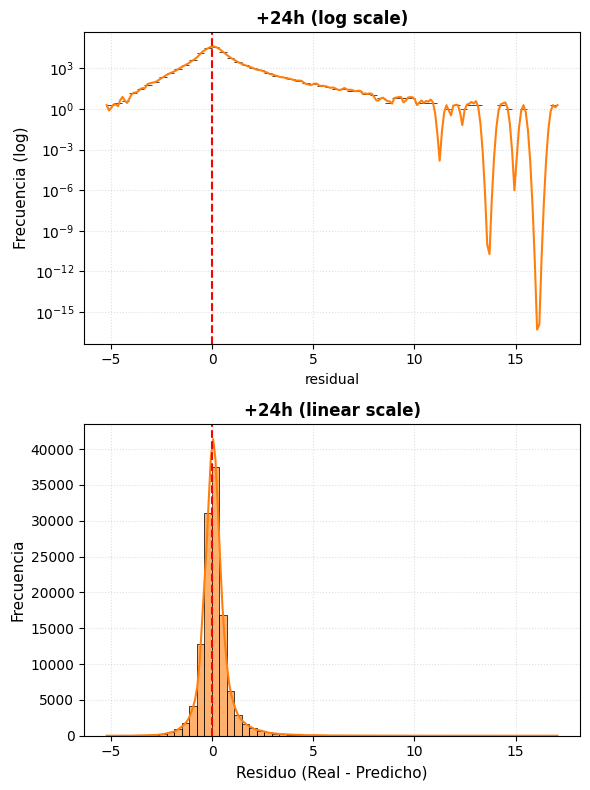

In [18]:
available_pred = {t: df for t, df in prediction_frames.items() if df is not None and not df.empty}

if available_pred:
    fig, axes = plt.subplots(2, len(available_pred), figsize=(6 * len(available_pred), 8), sharex=False)
    if len(available_pred) == 1:
        axes = np.array(axes).reshape(2, 1)

    for i, (target, df_plot) in enumerate(available_pred.items()):
        # -------- FILA 0: escala log --------
        ax_log = axes[0, i]
        sns.histplot(df_plot["residual"], bins=60, kde=True, ax=ax_log,
                     color="#ff7f0e", edgecolor="black", alpha=0.6, log_scale=(False, True))
        ax_log.axvline(0, color="red", linestyle="--", linewidth=1.5)
        ax_log.set_title(f"{HORIZON_LABELS[target]} (log scale)", fontsize=12, fontweight="bold")
        ax_log.grid(True, linestyle=":", alpha=0.4)

        # -------- FILA 1: escala normal --------
        ax_lin = axes[1, i]
        sns.histplot(df_plot["residual"], bins=60, kde=True, ax=ax_lin,
                     color="#ff7f0e", edgecolor="black", alpha=0.6)
        ax_lin.axvline(0, color="red", linestyle="--", linewidth=1.5)
        ax_lin.set_title(f"{HORIZON_LABELS[target]} (linear scale)", fontsize=12, fontweight="bold")
        ax_lin.grid(True, linestyle=":", alpha=0.4)

        if i == 0:
            ax_log.set_ylabel("Frecuencia (log)", fontsize=11)
            ax_lin.set_ylabel("Frecuencia", fontsize=11)
        ax_lin.set_xlabel("Residuo (Real - Predicho)", fontsize=11)

    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones reconstruidas para graficar residuos. Revisa la celda anterior si quieres generarlas desde el parquet y el modelo .pt.")


**5. Residuos vs. tiempo**

El análisis temporal de residuos sirve para detectar degradación progresiva, cambios de régimen o sesgos por temporada. El resultado numérico ya sugiere estabilidad: validation y test tienen rendimientos próximos, con $R^2$ **0.7558** y **0.7524** respectivamente.

La siguiente gráfica, cuando se dispone de predicciones reconstruidas, muestra residuos individuales por zona/hora y una media móvil de 24h. Un modelo estable debería mantener la tendencia cerca de cero durante el periodo de test.


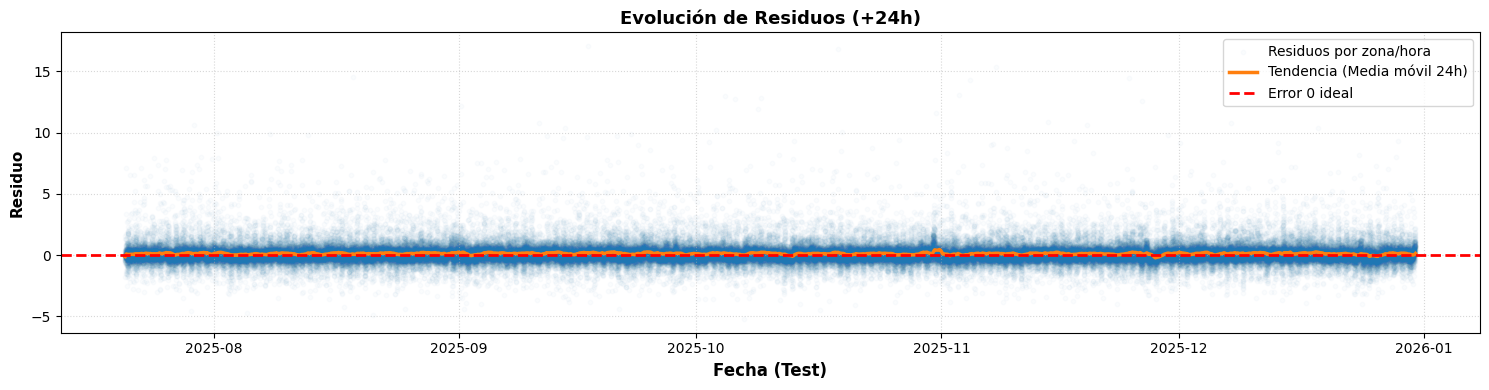

In [19]:
available_pred = {t: df for t, df in prediction_frames.items() if df is not None and not df.empty}

if available_pred:
    fig, axes = plt.subplots(len(available_pred), 1, figsize=(15, 4 * len(available_pred)), sharex=True)
    if len(available_pred) == 1:
        axes = [axes]

    for ax, (target, df_plot) in zip(axes, available_pred.items()):
        df_plot = df_plot.copy()
        df_plot["timestamp_hour"] = pd.to_datetime(df_plot["timestamp_hour"])
        df_plot = df_plot.sort_values("timestamp_hour")

        # Dibujar puntos individuales con opacidad baja para ver densidad
        ax.scatter(df_plot["timestamp_hour"], df_plot["residual"],
                   alpha=0.02, color="#1f77b4", s=10, label="Residuos por zona/hora")

        # Calcular residuo medio de toda la ciudad por hora
        df_mean = df_plot.groupby("timestamp_hour")["residual"].mean().reset_index()

        # Aplicar media móvil de 24h para ver la tendencia clara
        df_mean["rolling_res"] = df_mean["residual"].rolling(window=24, min_periods=1).mean()

        ax.plot(df_mean["timestamp_hour"], df_mean["rolling_res"],
                color="#ff7f0e", linewidth=2.5, label="Tendencia (Media móvil 24h)")

        # Línea ideal 0
        ax.axhline(0, color="red", linestyle="--", linewidth=2, label="Error 0 ideal")

        ax.set_title(f"Evolución de Residuos ({HORIZON_LABELS[target]})", fontsize=13, fontweight="bold")
        ax.set_ylabel("Residuo", fontsize=11, fontweight="bold")
        ax.legend(loc="upper right")
        ax.grid(True, linestyle=":", alpha=0.5)

    axes[-1].set_xlabel("Fecha (Test)", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No hay predicciones reconstruidas para graficar residuos temporales.")


**6. Curva de entrenamiento y early stopping**

La curva de entrenamiento muestra cómo evoluciona la función de pérdida `SmoothL1Loss`. En el experimento +24h, la validation loss mejora de forma clara hasta la época **8**, donde alcanza su mejor valor aproximado (**0.2151**). A partir de ahí se estabiliza y empeora ligeramente, por lo que el early stopping detiene el proceso en la época **13**.

Esto refuerza la lectura de generalización: el entrenamiento no se fuerza hasta memorizar el train completo, sino que se conserva el estado que mejor funciona en validation.


,epoch,train_loss,val_loss,lr,Target
0,1.0,0.247280,0.225012,0.0010,+24h
1,2.0,0.222330,0.225154,0.0010,+24h
2,3.0,0.217113,0.222900,0.0010,+24h
3,4.0,0.214667,0.220534,0.0010,+24h
4,5.0,0.213052,0.220386,0.0010,+24h
5,6.0,0.211956,0.222591,0.0010,+24h
6,7.0,0.211111,0.216371,0.0010,+24h
7,8.0,0.210610,0.215122,0.0010,+24h
8,9.0,0.210156,0.218711,0.0010,+24h
9,10.0,0.209789,0.217325,0.0010,+24h


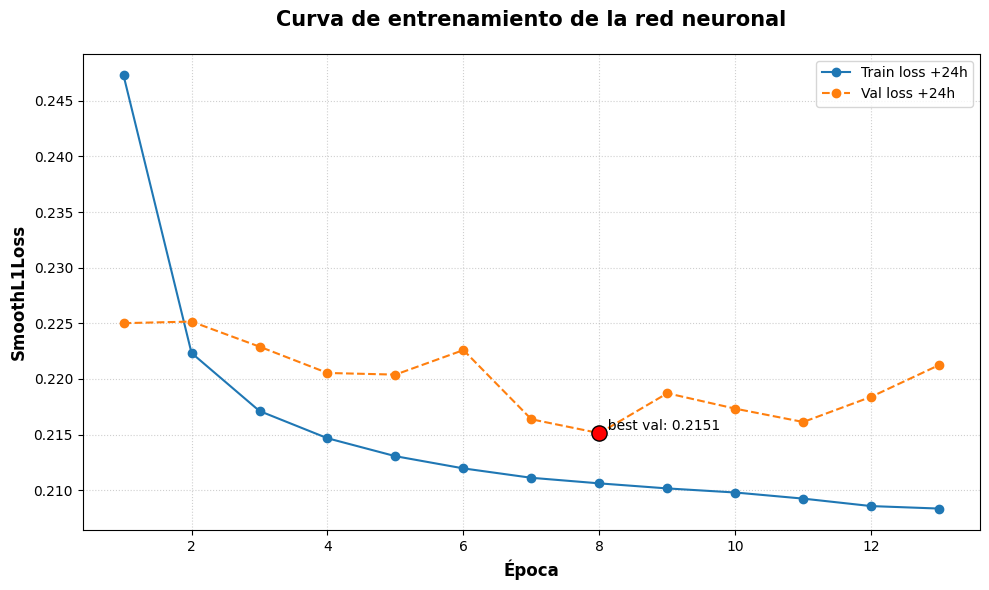

In [20]:
history_frames = []

for target, report in reports.items():
    hist = _load_history(target, report)
    if not hist.empty:
        hist = hist.copy()
        hist["Target"] = HORIZON_LABELS[target]
        history_frames.append(hist)

if history_frames:
    df_history = pd.concat(history_frames, ignore_index=True)
    display(df_history)

    plt.figure(figsize=(10, 6))
    for target_label, df_h in df_history.groupby("Target"):
        plt.plot(df_h["epoch"], df_h["train_loss"], marker="o", label=f"Train loss {target_label}")
        plt.plot(df_h["epoch"], df_h["val_loss"], marker="o", linestyle="--", label=f"Val loss {target_label}")

        best_idx = df_h["val_loss"].idxmin()
        best_row = df_h.loc[best_idx]
        plt.scatter(best_row["epoch"], best_row["val_loss"], color="red", s=120, zorder=5, edgecolors="black")
        plt.text(best_row["epoch"], best_row["val_loss"], f"  best val: {best_row['val_loss']:.4f}", va="bottom")

    plt.title("Curva de entrenamiento de la red neuronal", fontsize=15, fontweight="bold", pad=20)
    plt.xlabel("Época", fontsize=12, fontweight="bold")
    plt.ylabel("SmoothL1Loss", fontsize=12, fontweight="bold")
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("No se encontró historial de entrenamiento.")
